In [1]:
import os
import numpy as np
import pickle
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from Week567_General_Code_Question import load_mnist

In [2]:
batch_size = 128
train_loader, test_loader = load_mnist(batch_size=batch_size)
mnist_dim = 28 * 28 # 784
z_dim = 64

In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim, mnist_dim):
        super(Generator, self).__init__()
        # TODO：定义Generator的结构，基于Linear层
        # 输入维度为z_dim，输出维度为mnist_dim，即mnist的图片的像素总数
        self.linear1 = nn.Linear(z_dim, 128)
        self.linear2 = nn.Linear(128, 512)
        self.linear3 = nn.Linear(512, 1024)
        self.linear4 = nn.Linear(1024, mnist_dim)

        self.relu = nn.LeakyReLU(0.2, inplace=True)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # TODO：前向传播，最终记得将generator的输出范围限制在-1~1范围内（另外，助教也已经预先对真实图片做了预处理，像素值也在-1~1之间）
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.tanh(self.linear4(x)) # 将输出限制在-1~1范围内
        return x


class Discriminator(nn.Module):
    def __init__(self, mnist_dim):
        super(Discriminator, self).__init__()
        # TODO：定义Discriminator结构，可基于Linear层也可基于Conv2d层
        # 直接倒过来写，输入维度为mnist_dim，输出维度为1，表示输入图片为真实图片的概率
        self.linear1 = nn.Linear(mnist_dim, 1024)
        self.linear2 = nn.Linear(1024, 512)
        self.linear3 = nn.Linear(512, 256)
        self.linear4 = nn.Linear(256, 1)

        self.relu = nn.LeakyReLU(0.2, inplace=True)
        self.dropout = nn.Dropout(0.3) # 增加Dropout防止Discriminator过拟合和过强
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # TODO：前向传播，最终记得将Discriminator的输出范围限制在0~1范围内（表示概率）
        # MNIST的图片需要展平为一维向量，输入维度为mnist_dim
        x = x.view(x.size(0), -1) # 展平为(当前batch_size, mnist_dim)
        x = self.dropout(self.relu(self.linear1(x)))
        x = self.dropout(self.relu(self.linear2(x)))
        x = self.dropout(self.relu(self.linear3(x)))
        x = self.sigmoid(self.linear4(x))
        return x


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G = Generator(z_dim, mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)
print(G, D)

Generator(
  (linear1): Linear(in_features=64, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=512, bias=True)
  (linear3): Linear(in_features=512, out_features=1024, bias=True)
  (linear4): Linear(in_features=1024, out_features=784, bias=True)
  (relu): LeakyReLU(negative_slope=0.2, inplace=True)
  (tanh): Tanh()
) Discriminator(
  (linear1): Linear(in_features=784, out_features=1024, bias=True)
  (linear2): Linear(in_features=1024, out_features=512, bias=True)
  (linear3): Linear(in_features=512, out_features=256, bias=True)
  (linear4): Linear(in_features=256, out_features=1, bias=True)
  (relu): LeakyReLU(negative_slope=0.2, inplace=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)


In [5]:
lr = 0.0002
criterion = nn.BCELoss()
G_optimizer = torch.optim.Adam(G.parameters(), lr=lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr=lr)
G_loss_history = []
D_loss_history = []

epoch 0: D_loss 0.766, G_loss 3.592


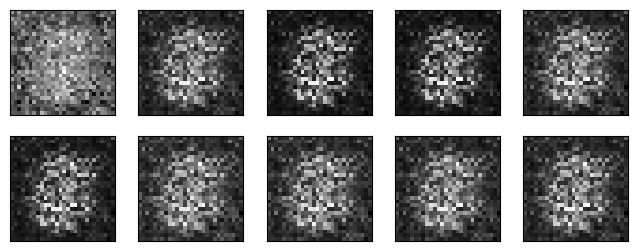

epoch 1: D_loss 0.761, G_loss 4.393
epoch 2: D_loss 0.932, G_loss 2.198
epoch 3: D_loss 0.802, G_loss 2.250


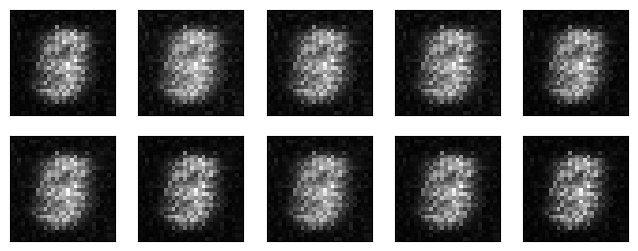

epoch 4: D_loss 0.513, G_loss 2.953
epoch 5: D_loss 0.336, G_loss 3.927
epoch 6: D_loss 0.480, G_loss 3.426


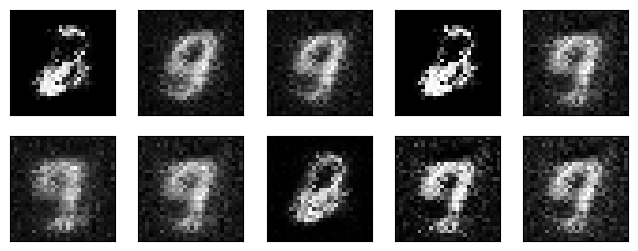

epoch 7: D_loss 0.376, G_loss 3.485
epoch 8: D_loss 0.469, G_loss 3.075
epoch 9: D_loss 0.449, G_loss 3.281


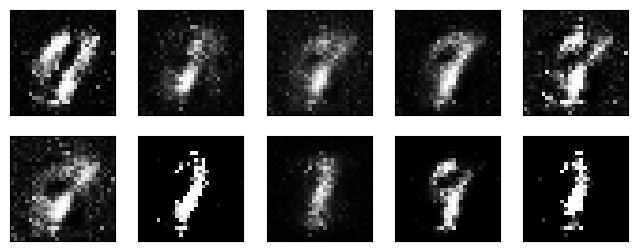

epoch 10: D_loss 0.480, G_loss 3.023
epoch 11: D_loss 0.538, G_loss 2.723
epoch 12: D_loss 0.595, G_loss 2.640


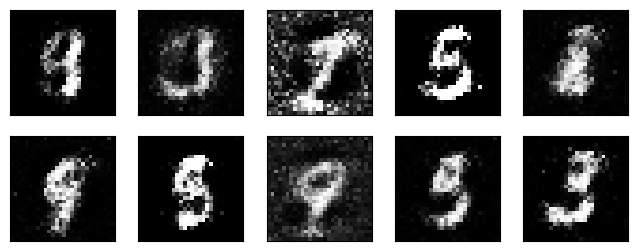

epoch 13: D_loss 0.626, G_loss 2.415
epoch 14: D_loss 0.632, G_loss 2.371
epoch 15: D_loss 0.661, G_loss 2.397


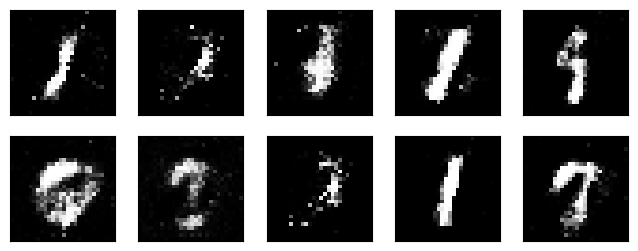

epoch 16: D_loss 0.675, G_loss 2.369
epoch 17: D_loss 0.727, G_loss 2.203
epoch 18: D_loss 0.708, G_loss 2.184


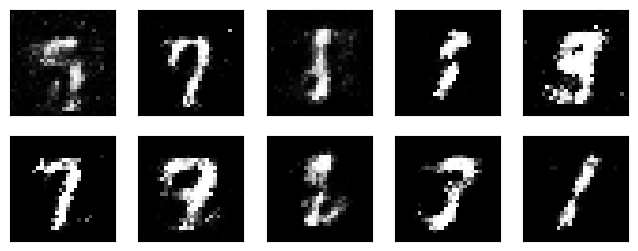

epoch 19: D_loss 0.678, G_loss 2.196
epoch 20: D_loss 0.679, G_loss 2.253
epoch 21: D_loss 0.776, G_loss 1.993


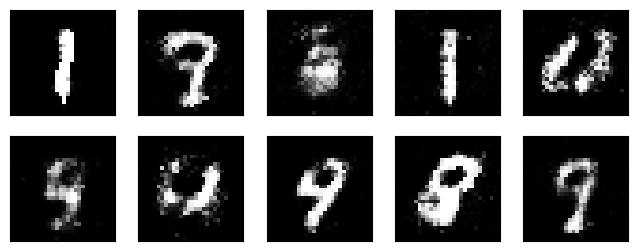

epoch 22: D_loss 0.771, G_loss 2.022
epoch 23: D_loss 0.766, G_loss 1.923
epoch 24: D_loss 0.784, G_loss 1.914


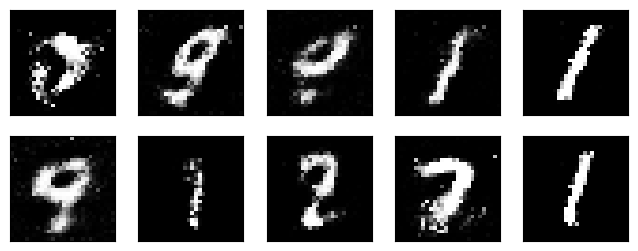

epoch 25: D_loss 0.832, G_loss 1.837
epoch 26: D_loss 0.831, G_loss 1.829
epoch 27: D_loss 0.882, G_loss 1.677


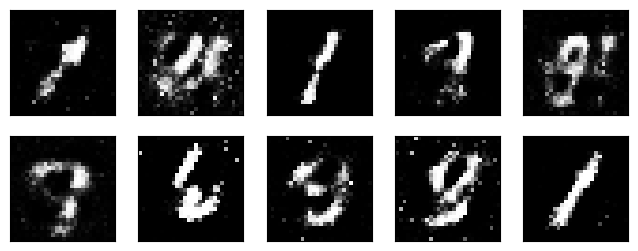

epoch 28: D_loss 0.864, G_loss 1.716
epoch 29: D_loss 0.872, G_loss 1.726


In [ ]:
epochs = 30
for e in range(epochs):
    D_loss_total = 0.0
    G_loss_total = 0.0
    # TODO：在这里对train_loader做遍历，训练GAN
    for batch_id, (real_xs, _) in enumerate(train_loader):
        curr_batch_size = real_xs.size(0)

        # TODO：训练Discriminator，希望真实图片分类为1，生成图片分类为0
        # 先生成一些随机噪声，输入Generator得到生成图片
        z = torch.randn(curr_batch_size, z_dim).to(device)  # 随机噪声，维度为(curr_batch_size, z_dim)
        fake_xs = G(z)  # 生成图片，维度为(curr_batch_size, mnist_dim)
        # 判别器希望对真实图片输出1，对生成图片输出0，因此将真实图片的目标标签设为1，生成图片的目标标签设为0
        real_labels = torch.ones(curr_batch_size, 1).to(device)
        fake_labels = torch.zeros(curr_batch_size, 1).to(device)
        D_optimizer.zero_grad()
        # 判别器的loss是对真实图片和生成图片的loss之和，注意fake_xs需要detach()，否则会影响Generator的训练
        D_loss = criterion(D(real_xs.to(device)), real_labels) + criterion(D(fake_xs.detach()), fake_labels)
        D_loss.backward()
        D_optimizer.step()
        D_loss_total += D_loss.item()

        # TODO：训练Generator，希望生成图片被识别为1（对抗Discriminator）
        # 再次进行生成，这里如果使用之前生成的fake_xs，效果会变差，产生一定的对抗样本效应
        # 因为上一次生成的fake_xs已经被Discriminator识别过了，且通过backward()更新了Discriminator的参数，让模型趋向于识别为0
        # 如果继续使用之前的fake_xs，Generator会受到之前训练的影响，产生一条判定冲突，因为我们现在又想让同一张图被识别为1，导致模式崩溃
        # 引入新的随机噪声，可以一定程度上缓解模式崩溃问题
        z1 = torch.randn(curr_batch_size, z_dim).to(device)
        fake_xs1 = G(z1)
        # 生成器希望对生成图片输出1，因此将生成图片的目标标签设为1
        G_optimizer.zero_grad()
        G_loss = criterion(D(fake_xs1), real_labels)
        G_loss.backward()
        G_optimizer.step()
        G_loss_total += G_loss.item()

    D_loss_avg = D_loss_total / len(train_loader)   # TODO：计算Discriminator在当前epoch内各个batch的平均loss
    G_loss_avg = G_loss_total / len(train_loader)   # TODO：计算Generator在当前epoch内各个batch的平均loss
    print('epoch %d: D_loss %.3f, G_loss %.3f' % (e, D_loss_avg, G_loss_avg))
    D_loss_history.append(D_loss_avg)
    G_loss_history.append(G_loss_avg)
    if e % 3 == 0:
        G.eval()
        G_gen = G(torch.randn((10, z_dim), device=device))
        imgs = G_gen.detach().cpu().data.numpy().reshape(G_gen.shape[0], 28, 28)

        fig = plt.figure(figsize=(8, 3))
        for idx, img in enumerate(imgs):
            ax = fig.add_subplot(2, 5, idx + 1)
            ax.imshow(img, cmap="gray")
            ax.set_xticks([])
            ax.set_yticks([])
        plt.show()

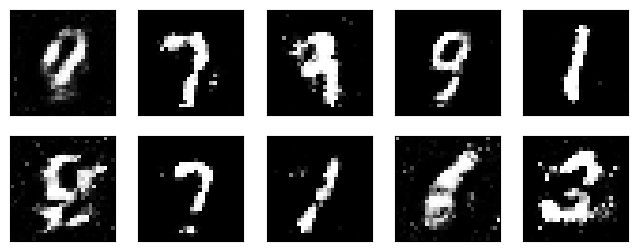

In [7]:
G.eval()
G_gen = G(torch.randn((10, z_dim), device=device))
imgs = G_gen.detach().cpu().data.numpy().reshape(G_gen.shape[0], 28, 28)

fig = plt.figure(figsize=(8, 3))
for idx, img in enumerate(imgs):
    ax = fig.add_subplot(2, 5, idx + 1)
    ax.imshow(img, cmap='gray') # 生成图片的像素值在-1~1之间，因此设置vmin和vmax参数将像素值映射到灰度图的颜色范围
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

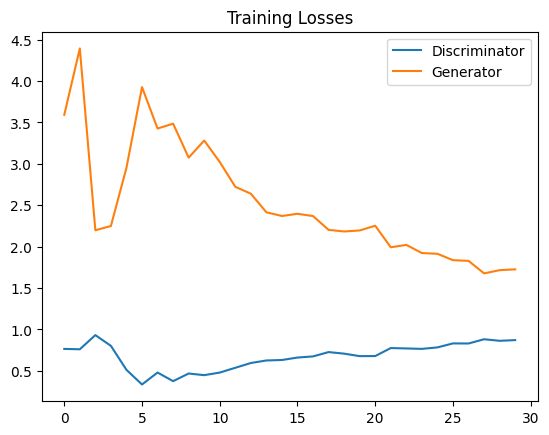

In [8]:
fig, ax = plt.subplots()
plt.plot(np.array(D_loss_history), label='Discriminator')
plt.plot(np.array(G_loss_history), label='Generator')
plt.title("Training Losses")
plt.legend()
plt.show()